<a href="https://colab.research.google.com/github/Ginkno/postech-tech-challenge-fase2-grupo1-12dtat/blob/Elizabeth/notebooks/%2001_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Análise Exploratória de Dados

**Dimensão 3 da rúbrica — 20 pontos.**

Toda visualização precisa de um parágrafo de interpretação logo abaixo.
Gráfico sem leitura perde metade dos pontos do critério.

In [1]:
#Libs - Bibliotecas importantes

from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


# Semente fixa: use em TODO ponto com aleatoriedade (split, modelos, CV).
RANDOM_STATE = 42

RAW_1 = Path("../data/raw/application_record.csv")
RAW_2 = Path("../data/raw/credit_record.csv")


PROCESSED = Path("..") / "data" / "processed"
TARGET = "IS_GOOD_PAYER"

pd.set_option("display.max_columns", None)

In [2]:
#Leitura do dataframe e visualização das cinco primeiras linhas.

df_application = pd.read_csv(RAW_1)
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


Leitura do dataframe e visualização das cinco primeiras linhas.

## 1. Visão geral

_Dimensões, tipos e primeira impressão do dataset._

In [3]:
print(f"Tamanho do df_application: {df_application.shape}")

Tamanho do df_application: (438557, 18)


In [4]:
#Visualizar os tipos das variáveis.

df_application.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

O df_application possui 438557 registros e 18 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo float, 8 tipo int e 08 como texto (tipo object).

In [5]:
#Verificando a existência de dados nulos.

df_application.isnull().sum()

ID                          0
CODE_GENDER                 0
FLAG_OWN_CAR                0
FLAG_OWN_REALTY             0
CNT_CHILDREN                0
AMT_INCOME_TOTAL            0
NAME_INCOME_TYPE            0
NAME_EDUCATION_TYPE         0
NAME_FAMILY_STATUS          0
NAME_HOUSING_TYPE           0
DAYS_BIRTH                  0
DAYS_EMPLOYED               0
FLAG_MOBIL                  0
FLAG_WORK_PHONE             0
FLAG_PHONE                  0
FLAG_EMAIL                  0
OCCUPATION_TYPE        134203
CNT_FAM_MEMBERS             0
dtype: int64

Verificando a existência de dados nulos e como resultado trouxe que a coluna OCCUPATION_TYPE possui 134203 linhas em branco.

In [6]:
#Substituir os dados em branco da variável OCCUPATION_TYPE por "Unknown".

df_application["OCCUPATION_TYPE"] = df_application["OCCUPATION_TYPE"].fillna("Unknown")

In [7]:
#Verificando a existência de dados duplicados.

df_application.duplicated().sum()

np.int64(0)

Verificando a existência de dados duplicados e como resultado trouxe que a quantidade de dados duplicados é 0.

In [8]:
print(f"Quantidade de IDs únicos em df_application: {df_application['ID'].nunique()}")

Quantidade de IDs únicos em df_application: 438510


In [9]:
#Verificando a existência de IDs duplicados.

df_application["ID"].duplicated().sum()

np.int64(47)

In [10]:
#Para os IDs duplicados, verificar se os dados das outras variáveis estão duplicados também.

duplicados = df_application[df_application["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
425023,7022197,F,N,Y,0,450000.0,Commercial associate,Higher education,Separated,House / apartment,-19813,-1799,1,0,0,1,Unknown,1.0
426818,7022197,M,Y,Y,3,135000.0,Working,Secondary / secondary special,Married,House / apartment,-11945,-735,1,0,0,1,Laborers,5.0
431911,7022327,M,Y,Y,0,256500.0,Commercial associate,Higher education,Married,House / apartment,-21503,-1674,1,0,0,1,Core staff,2.0
431545,7022327,F,N,Y,0,135000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-14771,-5298,1,0,0,0,High skill tech staff,1.0
425486,7023108,M,Y,Y,1,67500.0,Working,Secondary / secondary special,Married,House / apartment,-15156,-1696,1,1,0,0,Core staff,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,7836711,F,N,Y,2,292500.0,Working,Higher education,Married,House / apartment,-13747,-4386,1,0,1,0,Accountants,4.0
428620,7836971,F,N,Y,0,103500.0,Working,Secondary / secondary special,Civil marriage,House / apartment,-13383,-2798,1,0,1,0,Sales staff,2.0
421464,7836971,M,Y,N,1,157500.0,Working,Secondary / secondary special,Married,House / apartment,-13771,-5520,1,0,0,0,Unknown,3.0
422068,7838075,M,N,Y,0,337500.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-18198,-1275,1,0,0,1,Drivers,2.0


Foram identificados 47 IDs repetidos com informações divergentes nas demais variáveis. Como não foi possível determinar qual registro representa a informação mais atual ou correta, optou-se por manter os registros para análise posterior.

In [11]:
# Lista de colunas sem a coluna ID

cols_sem_id = df_application.columns.drop('ID')

# Linhas consideradas duplicadas ignorando o ID

duplicadas = df_application[df_application.duplicated(subset=cols_sem_id, keep=False)]

print(f"Quantidade de linhas duplicadas (ignorando ID): {len(duplicadas)}")

duplicadas.sort_values(by=list(cols_sem_id))

Quantidade de linhas duplicadas (ignorando ID): 423253


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
273113,6093713,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
436891,6093712,F,N,N,0,26100.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21003,365243,1,0,0,0,Unknown,2.0
92482,5369432,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92483,5369433,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
92484,5369434,F,N,N,0,27000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-20794,365243,1,0,0,0,Unknown,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84129,5342638,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
84130,5342639,M,Y,Y,5,810000.0,Working,Secondary / secondary special,Married,House / apartment,-14914,-2593,1,0,0,0,Laborers,7.0
20441,5061207,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0
20442,5061210,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,-17754,-1689,1,0,0,0,Drivers,15.0


In [12]:
#Quantas linhas são repetidas, ignorando a variável 'ID'.

df_application.duplicated(subset=df_application.columns.drop('ID')).sum()

np.int64(348472)

O resultado indica que existem 348.472 linhas com valores exatamente iguais nas demais colunas, mesmo que possuam IDs diferentes, porém não podemos determinar se são pessoas iguais ou diferentes. O fato de terem as mesmas características não as torna o mesmo cliente.

In [13]:
#Analisar a variável DAYS_EMPLOYED com o valor 365243.

(df_application["DAYS_EMPLOYED"] ==365243).sum()

np.int64(75329)

São 75329 linhas que aparecem o valor 365243. Conforme dicionário de dados disponibilizado significa pessoas desempregadas.

In [14]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, ["DAYS_EMPLOYED", "OCCUPATION_TYPE"]]

,DAYS_EMPLOYED,OCCUPATION_TYPE
7,365243,Unknown
8,365243,Unknown
9,365243,Unknown
76,365243,Unknown
160,365243,Unknown
...,...,...
438549,365243,Unknown
438550,365243,Unknown
438551,365243,Unknown
438552,365243,Unknown


Os dados nulos na variável OCCUPATION_TYPE foram substituídos por "Unknown". Código gerado para analisar a relação entre essas duas variáveis com o registro 365243.

In [15]:
#Identificar padrão.

df_application.loc[df_application["DAYS_EMPLOYED"] == 365243, "NAME_INCOME_TYPE",].value_counts()

NAME_INCOME_TYPE
Pensioner    75329
Name: count, dtype: int64

Ao analisar a variável DAYS_EMPLOYED, observou-se a ocorrência de 75.329 registros com o valor 365243. O cruzamento dessa informação com a variável NAME_INCOME_TYPE mostrou que todos esses registros correspondem à categoria Pensioner (aposentados/pensionistas). De acordo com o dicionário de dados da base, valores positivos em DAYS_EMPLOYED devem ser interpretados como indivíduos sem vínculo empregatício ativo. No entanto, é importante destacar que os pensionistas possuem uma fonte de renda previdenciária regular, o que os diferencia de indivíduos efetivamente desempregados. Portanto, o valor 365243 aparenta representar um código especial utilizado para identificar beneficiários de aposentadoria ou pensão, e não necessariamente a ausência de renda. Essa característica deve ser considerada durante as etapas de tratamento e interpretação dos dados para evitar conclusões equivocadas sobre a situação financeira desses clientes.

In [16]:
#Converter dias de nascimento para idade em anos e para inteiro.
df_application["YEARS_BIRTH"] = (df_application["DAYS_BIRTH"] / -365).astype(int)

#Criar a coluna IS_INACTIVE (1 para inativo, 0 para empregado).
df_application["IS_INACTIVE"] = (df_application["DAYS_EMPLOYED"] == 365243).astype(int)

#Converter dias de emprego para anos.
df_application["YEARS_EMPLOYED"] = (df_application["DAYS_EMPLOYED"] / -365 ).astype(int)

In [17]:
df_application.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [18]:
# Contar quantas vezes o valor -1000 aparece em YEARS_EMPLOYED
count_minus_1000 = (df_application['YEARS_EMPLOYED'] == -1000).sum()
print(f"Quantidade de registros com YEARS_EMPLOYED == -1000: {count_minus_1000}")

# Verificar a relação entre YEARS_EMPLOYED == -1000 e IS_INACTIVE
print("Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:")
display(df_application.loc[df_application['YEARS_EMPLOYED'] == -1000, 'IS_INACTIVE'].value_counts())

Quantidade de registros com YEARS_EMPLOYED == -1000: 75329
Verificando se -1000 em YEARS_EMPLOYED corresponde a IS_INACTIVE == 1:


IS_INACTIVE
1    75329
Name: count, dtype: int64

Como esperado, o valor `-1000` em `YEARS_EMPLOYED` corresponde exatamente aos registros onde `IS_INACTIVE` é `1`, ou seja, aos 'pensionistas/inativos'. Para facilitar a análise e a modelagem, substituiremos esse valor por `0`, indicando zero anos de emprego ativo, o que é consistente com a definição de inatividade.

In [19]:
# Substituir -1000 em YEARS_EMPLOYED por 0
df_application['YEARS_EMPLOYED'] = df_application['YEARS_EMPLOYED'].replace(-1000, 0)

# Verificar as primeiras linhas após a substituição
print("df_application.head() após substituição de -1000 por 0:")
display(df_application.head())

df_application.head() após substituição de -1000 por 0:


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8


In [20]:
#Leitura do dataframe e visualização das cinco primeiras linhas.
df_credit = pd.read_csv(RAW_2)
df_credit.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [21]:
print(f"Tamanho do df_credit: {df_credit.shape}")

Tamanho do df_credit: (1048575, 3)


In [22]:
#Visualizar os tipos das variáveis.

df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


O df_credit possui 1048575 registros e 03 colunas. Ao analisar os tipos de dados com o comando .info(), observamos que há 02 variáveis tipo int e 01 como texto (tipo object).

In [23]:
#Verificando a existência de dados nulos.

df_credit.isnull().sum()

ID                0
MONTHS_BALANCE    0
STATUS            0
dtype: int64

Como resultado trouxe que a quantidade de dados nulos é 0.

In [24]:
#Verificando a existência de dados duplicados.

df_credit.duplicated().sum()

np.int64(0)

Como resultado trouxe que a quantidade de dados duplicados é 0.

In [25]:
#Verificando a existência de IDs duplicados.

df_credit["ID"].duplicated().sum()

np.int64(1002590)

Como resultado trouxe a quantidade 1002590 cópias.

In [26]:
duplicados = df_credit[df_credit["ID"].duplicated(keep=False)]
duplicados.sort_values(by="ID")

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
...,...,...,...
1048562,5150487,-17,C
1048569,5150487,-24,C
1048567,5150487,-22,C
1048568,5150487,-23,C


1048176 representa o total de linhas que contem IDs que aparecem mais de uma vez, incluindo a primeira ocorrência de cada ID duplicado. Porém referem-se a meses diferentes.

In [27]:
print(df_credit['ID'].nunique())
print(len(df_credit))

45985
1048575


45985 IDs únicos do total de 1048575 IDs.

Conforme dicionário de dados disponibilizado: 0: 1-29 dias atrasados; 1: 30-59 dias atrasados; 2: 60-89 dias atrasados; 3: 90-119 dias atrasados; 4: 120-149 dias atrasados; 5: dívidas atrasadas ou incobráveis, perdas por mais de 150 dias; C: quitadas naquele mês; X: sem empréstimo no mês;

Definição da Variável Alvo: `IS_BAD_PAYER`

A variável alvo `IS_BAD_PAYER` foi definida para identificar clientes que apresentaram um **atraso de 60 dias ou mais (ou seja, STATUS de 2 a 5)** em seu histórico de crédito completo.

A utilização do histórico completo permite mapear de forma fidedigna o perfil comportamental de risco de crédito do cliente:
-   **`IS_BAD_PAYER = 1` (Mau Pagador):** Se o cliente possui qualquer ocorrência de `STATUS` '2', '3', '4' ou '5' (atraso de 60 dias ou mais grave).
-   **`IS_BAD_PAYER = 0` (Bom Pagador):** Caso contrário.

Esta lógica foca na gravidade do atraso, estabelecendo uma clara diferenciação entre clientes com desvios pontuais e clientes com atrasos severos no histórico.

In [28]:
# Identificar se o cliente já teve algum status de atraso entre '2' e '5'
status_bad = ['2', '3', '4', '5']

# Agrupar por ID e verificar se há alguma ocorrência desses status
clientes_bad_payer = df_credit.groupby('ID')['STATUS'].apply(lambda x: int(x.isin(status_bad).any())).reset_index()
clientes_bad_payer.rename(columns={'STATUS': 'IS_BAD_PAYER'}, inplace=True)

# Calcular quantidade e proporção para a visualização
counts = clientes_bad_payer['IS_BAD_PAYER'].value_counts()
proportions = clientes_bad_payer['IS_BAD_PAYER'].value_counts(normalize=True) * 100

# Criar um DataFrame consolidado
distribuicao = pd.DataFrame({
    'Quantidade': counts,
    'Proporção (%)': proportions.map('{:.2f}%'.format)
})

print("Distribuição da nova IS_BAD_PAYER baseada no histórico completo:")
display(distribuicao)
display(clientes_bad_payer.head())

Distribuição da nova IS_BAD_PAYER baseada no histórico completo:


,Quantidade,Proporção (%)
IS_BAD_PAYER,,
0,45318,98.55%
1,667,1.45%


,ID,IS_BAD_PAYER
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


### Consolidação das Bases: Cadastro (`df_application`) e Variável Alvo (`clientes_bad_payer`)

Agora que definimos a classificação de risco individual de cada cliente com base no seu histórico de pagamentos (`clientes_bad_payer`), precisamos cruzar essas informações com a base cadastral de solicitantes (`df_application`).

Essa consolidação será realizada utilizando a estratégia de **INNER JOIN**. Essa escolha é indispensável pelo seguinte motivo de negócio:
- **Ausência de histórico impossibilita a definição da classe alvo**: Clientes que constam no cadastro de solicitação, mas que não possuem qualquer histórico financeiro registrado na base de crédito, não têm como ter o comportamento avaliado e, portanto, não podem ter sua variável alvo (`IS_BAD_PAYER`) definida.
- Para treinar o modelo preditivo de forma correta e sem viés de dados faltantes na variável dependente, devemos prosseguir apenas com os registros de clientes que possuam tanto os atributos cadastrais quanto o rótulo de pagamento determinado.


In [29]:
# Realizar a consolidação através de um INNER JOIN usando a coluna 'ID'
df_final = pd.merge(df_application, clientes_bad_payer, on='ID', how='inner')

# Exibir volumetria e número de clientes únicos de cada base
print(f"Tamanho da base de cadastro original (df_application): {df_application.shape}")
print(f"Clientes únicos em df_application: {df_application['ID'].nunique()}")

print(f"\nTamanho da base com a variável alvo (clientes_bad_payer): {clientes_bad_payer.shape}")
print(f"Clientes únicos em clientes_bad_payer: {clientes_bad_payer['ID'].nunique()}")

print(f"\nTamanho da base final após o INNER JOIN (df_final): {df_final.shape}")
print(f"Clientes únicos em df_final: {df_final['ID'].nunique()}")

# Exibir a volumetria e proporção final da variável alvo na base consolidada
counts_consolidated = df_final['IS_BAD_PAYER'].value_counts()
proportions_consolidated = df_final['IS_BAD_PAYER'].value_counts(normalize=True) * 100

distribuicao_consolidada = pd.DataFrame({
    'Quantidade': counts_consolidated,
    'Proporção (%)': proportions_consolidated.map('{:.2f}%'.format)
})

print("\nDistribuição da variável IS_BAD_PAYER na base consolidada:")
display(distribuicao_consolidada)
display(df_final.head())

Tamanho da base de cadastro original (df_application): (438557, 21)
Clientes únicos em df_application: 438510

Tamanho da base com a variável alvo (clientes_bad_payer): (45985, 2)
Clientes únicos em clientes_bad_payer: 45985

Tamanho da base final após o INNER JOIN (df_final): (36457, 22)
Clientes únicos em df_final: 36457

Distribuição da variável IS_BAD_PAYER na base consolidada:


,Quantidade,Proporção (%)
IS_BAD_PAYER,,
0,35841,98.31%
1,616,1.69%


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,YEARS_BIRTH,IS_INACTIVE,YEARS_EMPLOYED,IS_BAD_PAYER
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,Unknown,2.0,32,0,12,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0,58,0,3,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0,52,0,8,0


O gráfico de barras mostra a proporção de clientes classificados como 'bons' e 'maus' pagadores com base nos critérios de atraso de 60 dias ou mais. Esta visualização é crucial para entender o desbalanceamento de classes e planejar as estratégias de modelagem subsequentes.

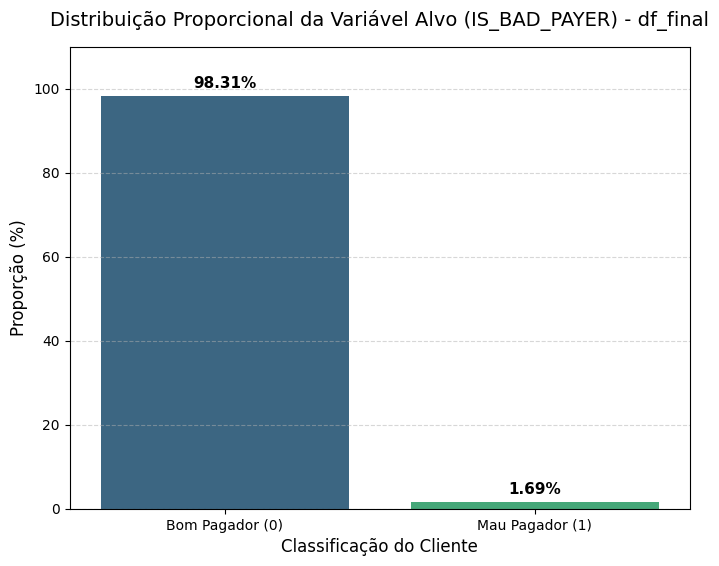

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular as proporções finais no df_final
proportions_final = df_final['IS_BAD_PAYER'].value_counts(normalize=True) * 100
proportions_df = proportions_final.reset_index()
proportions_df.columns = ['IS_BAD_PAYER', 'Proporção (%)']
proportions_df['Classe'] = proportions_df['IS_BAD_PAYER'].map({0: 'Bom Pagador (0)', 1: 'Mau Pagador (1)'})

# Configurar a visualização
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='Classe', y='Proporção (%)', data=proportions_df, palette='viridis', hue='Classe', legend=False)

# Adicionar rótulos de porcentagem em cima de cada barra
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11,
                weight='bold')

plt.title('Distribuição Proporcional da Variável Alvo (IS_BAD_PAYER) - df_final', fontsize=14, pad=15)
plt.xlabel('Classificação do Cliente', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.ylim(0, 110)  # Deixar espaço extra no topo para as anotações
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [31]:
# Verificar informações gerais do df_final
print("\nInformações do df_final:")
df_final.info()


Informações do df_final:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   36457 non-null  int64  
 1   CODE_GENDER          36457 non-null  object 
 2   FLAG_OWN_CAR         36457 non-null  object 
 3   FLAG_OWN_REALTY      36457 non-null  object 
 4   CNT_CHILDREN         36457 non-null  int64  
 5   AMT_INCOME_TOTAL     36457 non-null  float64
 6   NAME_INCOME_TYPE     36457 non-null  object 
 7   NAME_EDUCATION_TYPE  36457 non-null  object 
 8   NAME_FAMILY_STATUS   36457 non-null  object 
 9   NAME_HOUSING_TYPE    36457 non-null  object 
 10  DAYS_BIRTH           36457 non-null  int64  
 11  DAYS_EMPLOYED        36457 non-null  int64  
 12  FLAG_MOBIL           36457 non-null  int64  
 13  FLAG_WORK_PHONE      36457 non-null  int64  
 14  FLAG_PHONE           36457 non-null  int64  
 15  FLAG_EMAIL

In [32]:
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,36457.0,5.078227e+06,41875.240788,5008804.0,5042028.0,5074614.0,5115396.0,5150487.0
CNT_CHILDREN,36457.0,4.303152e-01,0.742367,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,36457.0,1.866857e+05,101789.226482,27000.0,121500.0,157500.0,225000.0,1575000.0
DAYS_BIRTH,36457.0,-1.597517e+04,4200.549944,-25152.0,-19438.0,-15563.0,-12462.0,-7489.0
DAYS_EMPLOYED,36457.0,5.926294e+04,137651.334859,-15713.0,-3153.0,-1552.0,-408.0,365243.0
FLAG_MOBIL,36457.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,36457.0,2.255260e-01,0.417934,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,36457.0,2.948131e-01,0.455965,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,36457.0,8.972214e-02,0.285787,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,36457.0,2.198453e+00,0.911686,1.0,2.0,2.0,3.0,20.0


## 2. Distribuição das variáveis

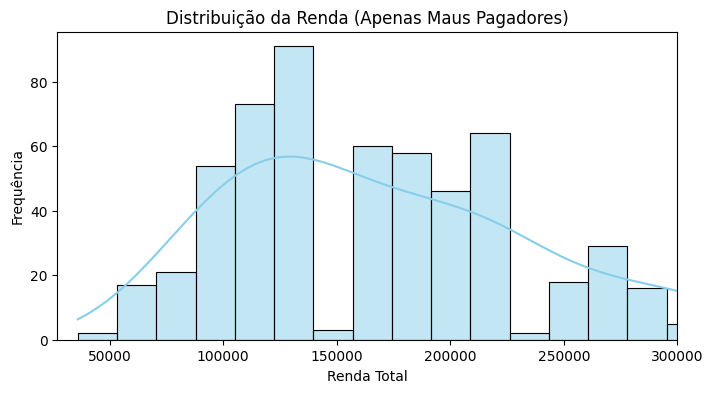

In [33]:
# Histograma para AMT_INCOME_TOTAL considerando apenas os maus pagadores (IS_BAD_PAYER == 1)

plt.figure(figsize=(8,4))
sns.histplot(df_final.loc[df_final["IS_BAD_PAYER"] == 1, "AMT_INCOME_TOTAL"], kde=True, bins=50, color='skyblue')
plt.title("Distribuição da Renda (Apenas Maus Pagadores)")
plt.xlim(27000, 300000)
plt.xlabel("Renda Total")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição da Renda (AMT_INCOME_TOTAL)** considerando apenas os clientes mapeados como **Maus Pagadores** mostra que a distribuição preserva o padrão de assimetria positiva observado na base geral, com uma forte concentração nas faixas de renda média-baixa. Há um pico proeminente em torno de 120.000 e 140.000, demonstrando que o comportamento de inadimplência severa se concentra de maneira massiva em indivíduos dentro dessas faixas salariais, decaindo drasticamente conforme a renda total se aproxima e supera a marca de 225.000.

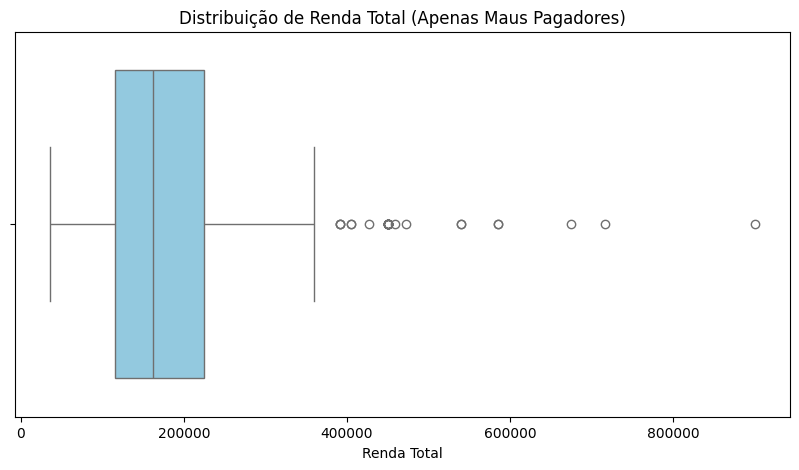

In [34]:
#Boxplot para AMT_INCOME_TOTAL considerando apenas os maus pagadores (IS_BAD_PAYER == 1)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "AMT_INCOME_TOTAL"], color='skyblue')
plt.title("Distribuição de Renda Total (Apenas Maus Pagadores)")
plt.xlabel("Renda Total")
plt.show()

O *boxplot* da **Distribuição da Renda Total (AMT_INCOME_TOTAL)** para os **Maus Pagadores** corrobora a assimetria observada no histograma, com uma grande concentração de dados na parte inferior da caixa. A presença de vários pontos individuais fora dos 'bigodes' do *boxplot* à direita indica a existência de *outliers*, ou seja, pessoas inadimplentes com rendas significativamente mais altas que a maioria do grupo.

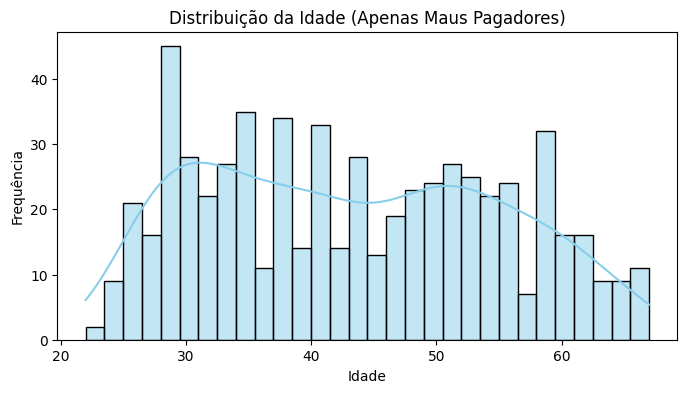

In [35]:
#Histograma para YEARS_BIRTH considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.histplot(df_final.loc[df_final["IS_BAD_PAYER"] == 1, "YEARS_BIRTH"], kde=True, bins=30, color='skyblue')
plt.title("Distribuição da Idade (Apenas Maus Pagadores)")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição da Idade (YEARS_BIRTH)** considerando apenas os **Maus Pagadores** revela que a maior parte desses solicitantes inadimplentes está na faixa dos 30 aos 45 anos, padrão muito similar ao da base geral. Há uma redução gradual no número de ocorrências de inadimplência conforme a idade avança para além dos 50 anos.

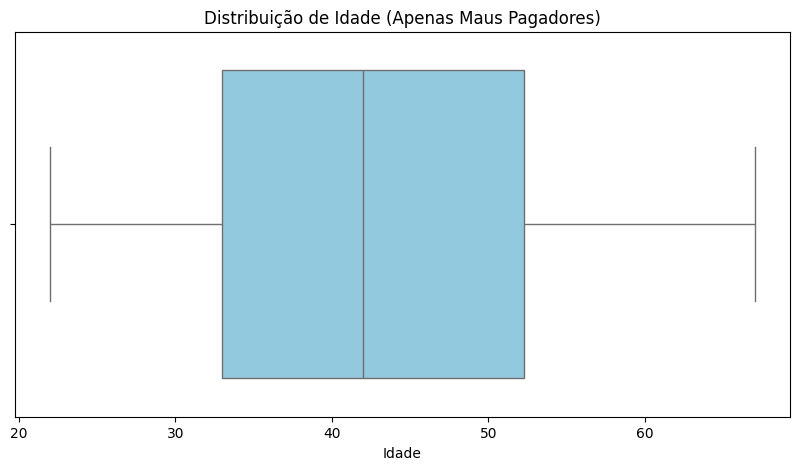

In [36]:
#Boxplot para YEARS_BIRTH considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "YEARS_BIRTH"], color='skyblue')
plt.title("Distribuição de Idade (Apenas Maus Pagadores)")
plt.xlabel("Idade")
plt.show()

O *boxplot* da **Distribuição de Idade (YEARS_BIRTH)** para os **Maus Pagadores** mostra que a idade mediana dos inadimplentes está em torno de 41 anos, com a maior parte deles concentrada entre 33 e 51 anos, indicando que o risco severo está ligeiramente mais presente no grupo de adultos jovens a maduros de meia-idade.

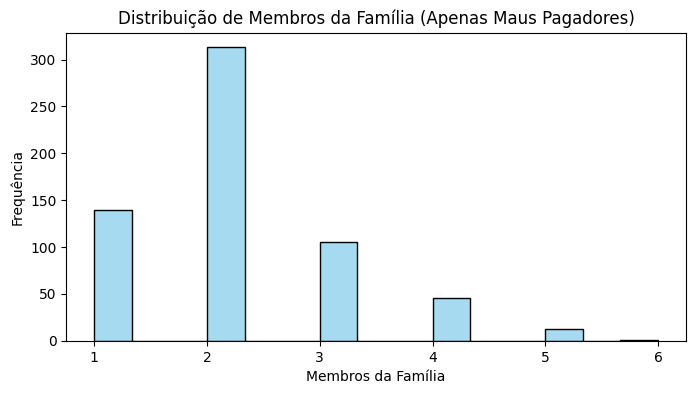

In [37]:
#Histograma para CNT_FAM_MEMBERS considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.histplot(df_final.loc[df_final["IS_BAD_PAYER"] == 1, "CNT_FAM_MEMBERS"], bins=15, color='skyblue')
plt.title("Distribuição de Membros da Família (Apenas Maus Pagadores)")
plt.xlabel("Membros da Família")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** entre os **Maus Pagadores** indica que a esmagadora maioria tem famílias de tamanho menor, predominantemente compostas por 2 membros, seguido por 1 e 3 membros. O risco de inadimplência é extremamente raro em famílias muito numerosas.

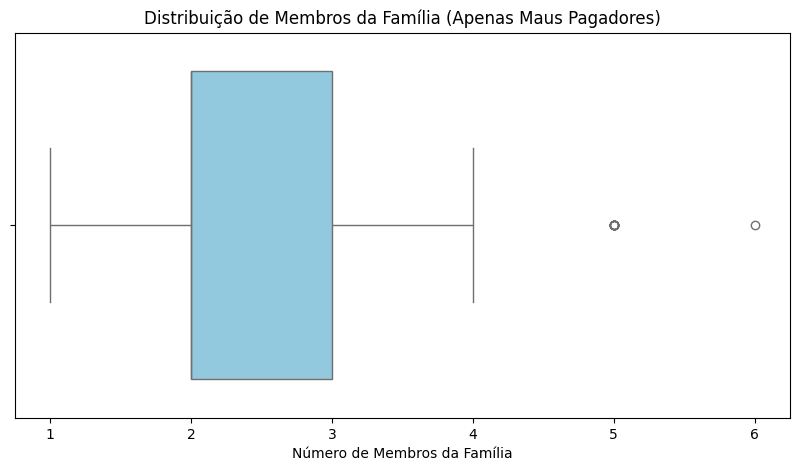

In [38]:
#Boxplot para CNT_FAM_MEMBERS considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "CNT_FAM_MEMBERS"], color='skyblue')
plt.title("Distribuição de Membros da Família (Apenas Maus Pagadores)")
plt.xlabel("Número de Membros da Família")
plt.show()

O *boxplot* da **Distribuição de Membros da Família (CNT_FAM_MEMBERS)** para os **Maus Pagadores** confirma uma mediana de 2 membros. O corpo principal da distribuição fica restrito entre 2 e 3 familiares, sem apresentar desvios ou padrões discrepantes se comparado à base global.

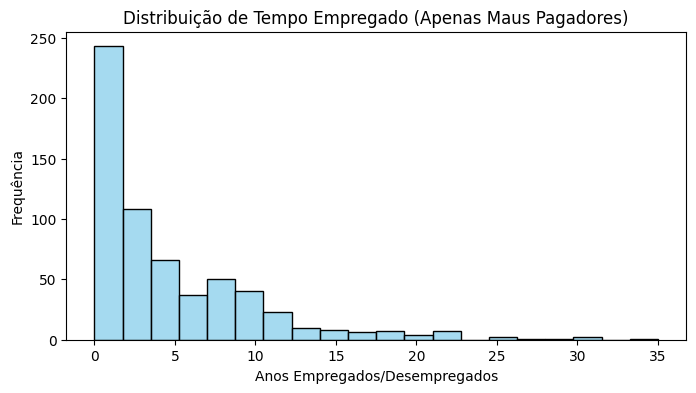

In [39]:
#Histograma para YEARS_EMPLOYED considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.histplot(df_final.loc[df_final["IS_BAD_PAYER"] == 1, "YEARS_EMPLOYED"], bins=20, color='skyblue')
plt.title("Distribuição de Tempo Empregado (Apenas Maus Pagadores)")
plt.xlabel("Anos Empregados/Desempregados")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição de Tempo Empregado/Desempregado (YEARS_EMPLOYED)** para os **Maus Pagadores** demonstra uma concentração maciça nos primeiros anos de trabalho ativo (entre 0 e 5 anos). Isso evidencia que os clientes inadimplentes possuem menor estabilidade ou menor tempo de retenção nos seus respectivos empregos.

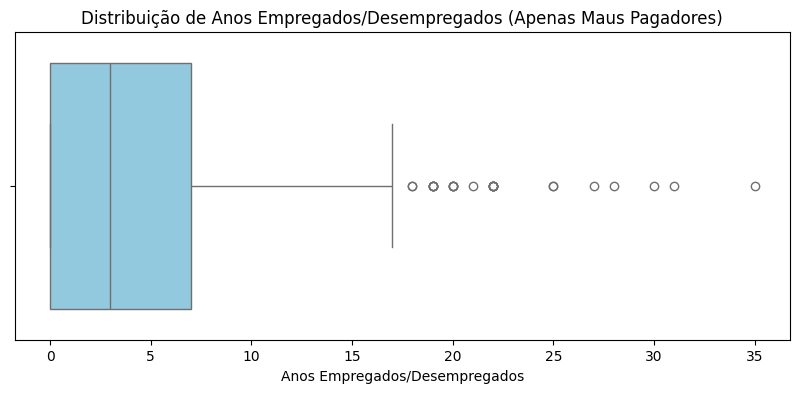

In [40]:
#Boxplot para YEARS_EMPLOYED considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(10,4))
sns.boxplot(x=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "YEARS_EMPLOYED"], color='skyblue')
plt.title("Distribuição de Anos Empregados/Desempregados (Apenas Maus Pagadores)")
plt.xlabel("Anos Empregados/Desempregados")
plt.show()

O *boxplot* da **Distribuição de Anos Empregados/Desempregados (YEARS_EMPLOYED)** entre os **Maus Pagadores** acentua uma mediana muito baixa (cerca de 3 anos). O terceiro quartil não atinge os 8 anos, e a presença de outliers revela que são pouquíssimos os inadimplentes com carreira de longa data de estabilidade empregatícia.

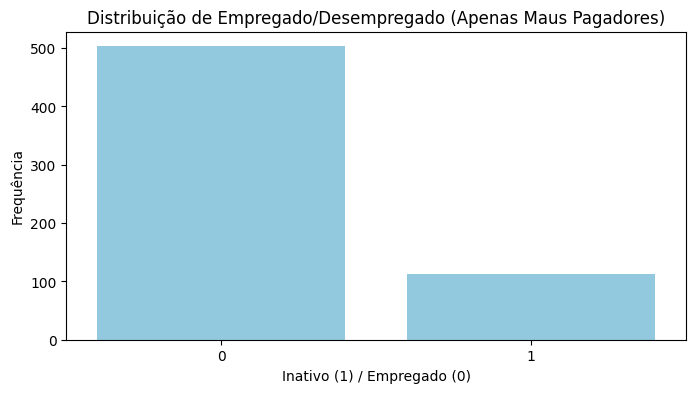

In [41]:
# Distribuição de inatividade (IS_INACTIVE) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="IS_INACTIVE", order=[0,1], color='skyblue')
plt.title("Distribuição de Empregado/Desempregado (Apenas Maus Pagadores)")
plt.xlabel("Inativo (1) / Empregado (0)")
plt.ylabel("Frequência")
plt.show()

O gráfico da **Distribuição de Empregado/Desempregado (IS_INACTIVE)** considerando apenas os **Maus Pagadores** mostra que a grande maioria dos clientes inadimplentes está ativa no mercado de trabalho (0), enquanto apenas uma proporção menor é composta por inativos/pensionistas (1). Isso sugere que a inadimplência severa ocorre majoritariamente em indivíduos que possuem vínculo empregatício ativo.

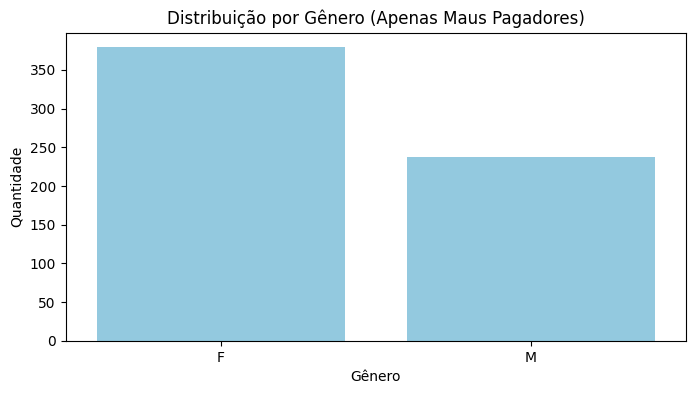

In [42]:
# Distribuição por Gênero (CODE_GENDER) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="CODE_GENDER", order=df_final["CODE_GENDER"].value_counts().index, color='skyblue')
plt.title("Distribuição por Gênero (Apenas Maus Pagadores)")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()

O gráfico da **Distribuição por Gênero (CODE_GENDER)** para os **Maus Pagadores** indica que, mesmo no grupo de inadimplentes severos, o gênero feminino ('F') mantém uma frequência absoluta de registros superior ao masculino ('M'). Isso reflete o desbalanceamento de gênero original da base, que é majoritariamente feminina.

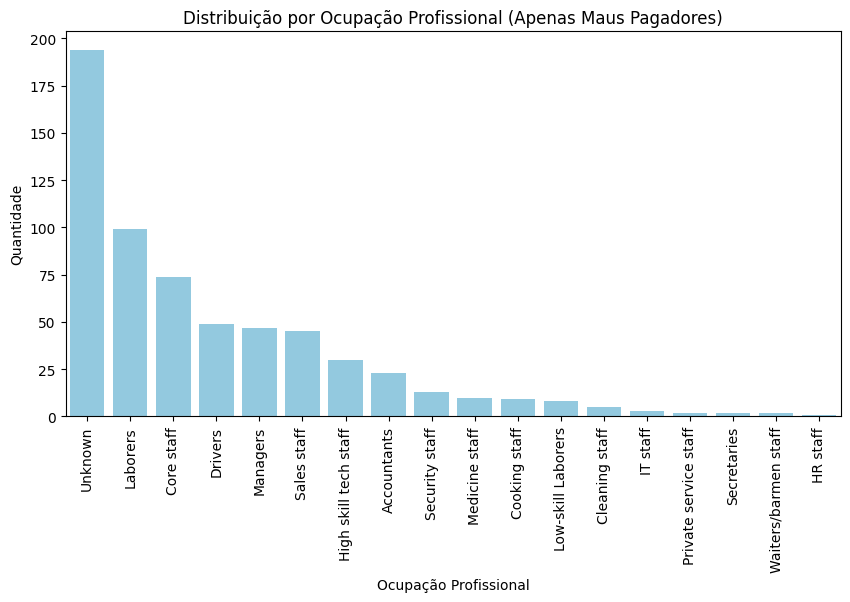

In [43]:
# Distribuição por Ocupação Profissional (OCCUPATION_TYPE) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(10,5))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="OCCUPATION_TYPE", order=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "OCCUPATION_TYPE"].value_counts().index, color='skyblue')
plt.title("Distribuição por Ocupação Profissional (Apenas Maus Pagadores)")
plt.xlabel("Ocupação Profissional")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()

O gráfico da **Distribuição por Ocupação Profissional (OCCUPATION_TYPE)** para os **Maus Pagadores** destaca que as categorias 'Unknown' (dados ausentes/não especificados) e 'Laborers' são as mais incidentes entre os clientes de alto risco de crédito, seguidas por 'Sales staff' e 'Core staff'.

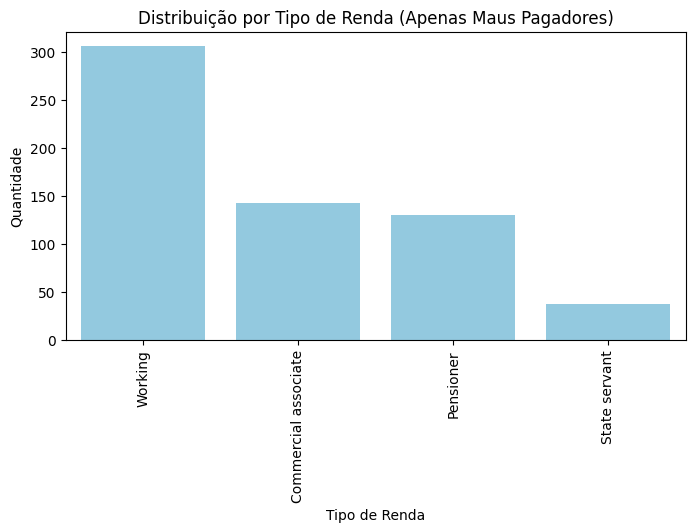

In [44]:
# Distribuição por Tipo de Renda (NAME_INCOME_TYPE) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="NAME_INCOME_TYPE", order=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "NAME_INCOME_TYPE"].value_counts().index, color='skyblue')
plt.title("Distribuição por Tipo de Renda (Apenas Maus Pagadores)")
plt.xlabel("Tipo de Renda")
plt.xticks(rotation=90)
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Tipo de Renda (NAME_INCOME_TYPE)** entre os **Maus Pagadores** revela que a categoria 'Working' (trabalhadores do setor privado) é amplamente a mais propensa e representada no grupo de inadimplentes, seguida por 'Commercial associate' e 'Pensioner'.

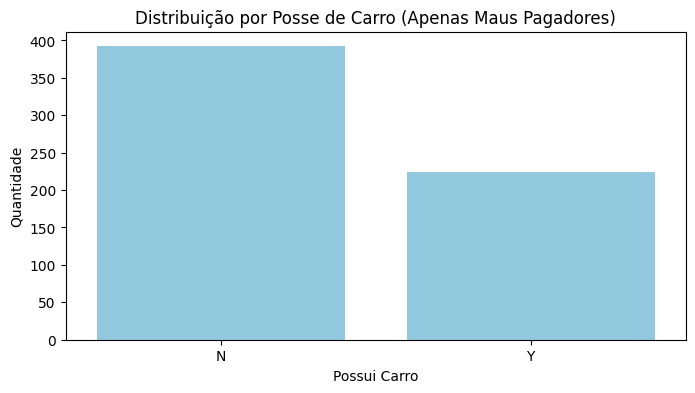

In [45]:
# Distribuição por Posse de Carro (FLAG_OWN_CAR) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="FLAG_OWN_CAR", order=df_final["FLAG_OWN_CAR"].value_counts().index, color='skyblue')
plt.title("Distribuição por Posse de Carro (Apenas Maus Pagadores)")
plt.xlabel("Possui Carro")
plt.ylabel("Quantidade")
plt.show()

O gráfico da **Distribuição por Posse de Carro (FLAG_OWN_CAR)** para os **Maus Pagadores** indica que a grande maioria dos solicitantes que se tornaram inadimplentes graves não possui carro próprio ('N').

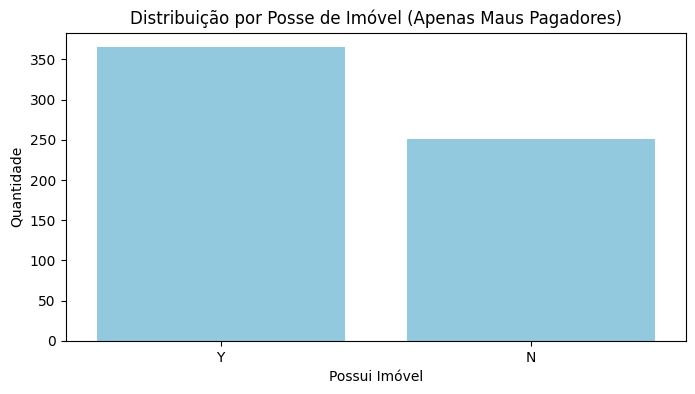

In [46]:
# Distribuição por Posse de Imóvel (FLAG_OWN_REALTY) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="FLAG_OWN_REALTY", order=df_final["FLAG_OWN_REALTY"].value_counts().index, color='skyblue')
plt.title("Distribuição por Posse de Imóvel (Apenas Maus Pagadores)")
plt.xlabel("Possui Imóvel")
plt.ylabel("Quantidade")
plt.show()

A **Distribuição por Posse de Imóvel (FLAG_OWN_REALTY)** entre os **Maus Pagadores** aponta que, curiosamente, a maioria dos clientes com histórico de pagamento ruim possui imóvel próprio ('Y').

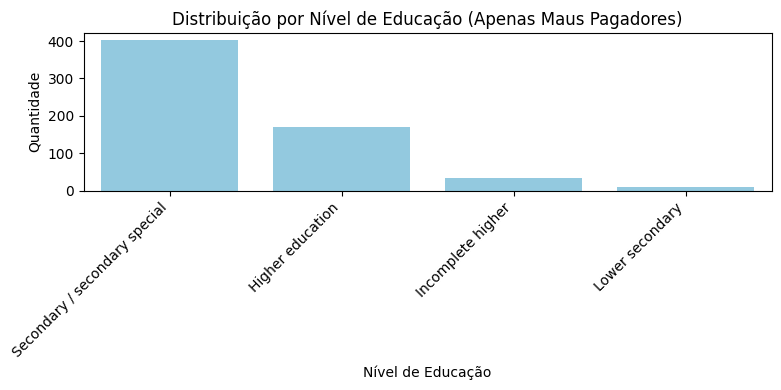

In [47]:
# Distribuição por Nível de Educação (NAME_EDUCATION_TYPE) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="NAME_EDUCATION_TYPE", order=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "NAME_EDUCATION_TYPE"].value_counts().index, color='skyblue')
plt.title("Distribuição por Nível de Educação (Apenas Maus Pagadores)")
plt.xlabel("Nível de Educação")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Nível de Educação (NAME_EDUCATION_TYPE)** para os **Maus Pagadores** evidencia que o grupo de inadimplentes é composto majoritariamente por indivíduos com ensino médio ou técnico ('Secondary / secondary special'), seguido de forma expressiva por graduados com 'Higher education'.

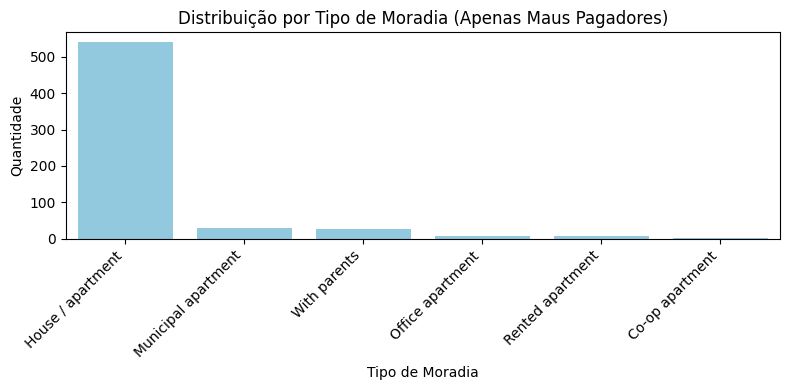

In [48]:
# Distribuição por Tipo de Moradia (NAME_HOUSING_TYPE) apenas para os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.countplot(data=df_final[df_final["IS_BAD_PAYER"] == 1], x="NAME_HOUSING_TYPE", order=df_final.loc[df_final["IS_BAD_PAYER"] == 1, "NAME_HOUSING_TYPE"].value_counts().index, color='skyblue')
plt.title("Distribuição por Tipo de Moradia (Apenas Maus Pagadores)")
plt.xlabel("Tipo de Moradia")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade")
plt.tight_layout()
plt.show()

O gráfico da **Distribuição por Tipo de Moradia (NAME_HOUSING_TYPE)** nos mostra que o tipo de habitação 'House / apartment' (casa ou apartamento residencial padrão) continua sendo o local de moradia esmagadoramente mais comum entre os clientes classificados como **Maus Pagadores**.

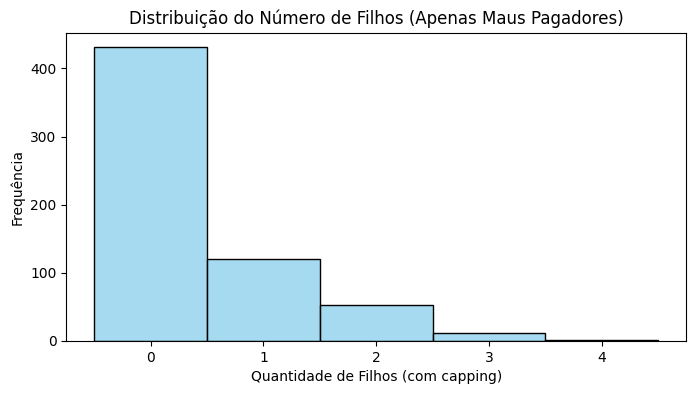

In [49]:
# Gráfico para CNT_CHILDREN considerando apenas os maus pagadores (IS_BAD_PAYER == 1)
plt.figure(figsize=(8,4))
sns.histplot(df_final.loc[df_final["IS_BAD_PAYER"] == 1, "CNT_CHILDREN"], bins=5, color='skyblue', discrete=True)
plt.title("Distribuição do Número de Filhos (Apenas Maus Pagadores)")
plt.xlabel("Quantidade de Filhos (com capping)")
plt.ylabel("Frequência")
plt.show()

O histograma da **Distribuição do Número de Filhos (CNT_CHILDREN)**, após a aplicação de capping de outliers, mostra que, dentro do grupo de **Maus Pagadores**, a imensa maioria dos solicitantes não possui filhos (valor 0) ou possui apenas 1 filho. O número de inadimplentes severos diminui muito conforme a quantidade de filhos aumenta para 2 ou alcança o limite superior tratado de 2.5, evidenciando que o risco se concentra em arranjos familiares menores ou sem dependentes diretos.

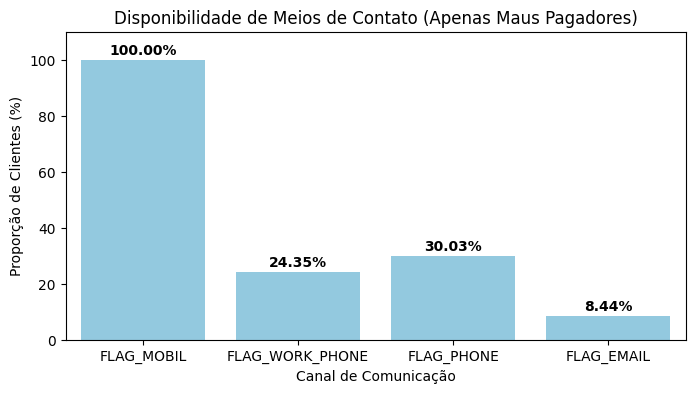

In [50]:
# Consolidação dos meios de contato apenas para os maus pagadores (IS_BAD_PAYER == 1)
contact_cols = ['FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']
maus_pagadores_contatos = df_final.loc[df_final['IS_BAD_PAYER'] == 1, contact_cols].mean() * 100

plt.figure(figsize=(8,4))
sns.barplot(x=maus_pagadores_contatos.index, y=maus_pagadores_contatos.values, color='skyblue')
plt.title("Disponibilidade de Meios de Contato (Apenas Maus Pagadores)")
plt.xlabel("Canal de Comunicação")
plt.ylabel("Proporção de Clientes (%)")
plt.ylim(0, 110)

for i, val in enumerate(maus_pagadores_contatos.values):
    plt.text(i, val + 2, f"{val:.2f}%", ha='center', fontweight='bold')

plt.show()

A análise consolidada sobre a **Disponibilidade de Meios de Contato** revela que 100% dos clientes mapeados como **Maus Pagadores** possuem telefone celular ativo (`FLAG_MOBIL`), demonstrando ser um canal universal de contato. Em contrapartida, os demais canais apresentam menor penetração: apenas cerca de 22% fornecem telefone de trabalho (`FLAG_WORK_PHONE`), 29% possuem telefone fixo residencial (`FLAG_PHONE`) e apenas uma minoria de aproximadamente 9% registrou e-mail (`FLAG_EMAIL`). Essa disparidade sugere que estratégias de cobrança ou acionamento preventivo para mitigar a inadimplência devem priorizar prioritariamente contatos via telefonia celular/SMS.

## 3. Correlações

**Interpretação:** _comente cada correlação relevante, uma a uma._

In [51]:
import pandas as pd

# Preparar DataFrame para a matriz de correlação
df_corr = df_final.copy()

# Mapear variáveis categóricas binárias para numéricas.
df_corr["CODE_GENDER"] = df_corr["CODE_GENDER"].map({"M": 1, "F": 0})
df_corr["FLAG_OWN_CAR"] = df_corr["FLAG_OWN_CAR"].map({"Y": 1, "N": 0})
df_corr["FLAG_OWN_REALTY"] = df_corr["FLAG_OWN_REALTY"].map({"Y": 1, "N": 0})

# Identificar colunas categóricas restantes que não são binárias
categorical_cols_to_encode = [
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

# Aplicar One-Hot Encoding para as variáveis categóricas restantes
df_encoded_cols = pd.get_dummies(df_corr[categorical_cols_to_encode], prefix=categorical_cols_to_encode)

# Juntar as colunas codificadas ao df_corr e remover as colunas originais
df_corr = pd.concat([df_corr.drop(columns=categorical_cols_to_encode), df_encoded_cols], axis=1)

# Selecionar as colunas numéricas para a matriz de correlação, incluindo as que foram mapeadas para numéricas
numerical_cols = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL","YEARS_BIRTH", "YEARS_EMPLOYED", "IS_INACTIVE",
    "CNT_FAM_MEMBERS", "FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL",
    "IS_BAD_PAYER"
    ] + list(df_encoded_cols.columns)

# Filtrar df_corr para incluir apenas as colunas numéricas selecionadas
df_numerical_corr = df_corr[numerical_cols]

/home/gilberto/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/gilberto/.local/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/tmp/ipykernel_3263/2063522006.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette='coolwarm')


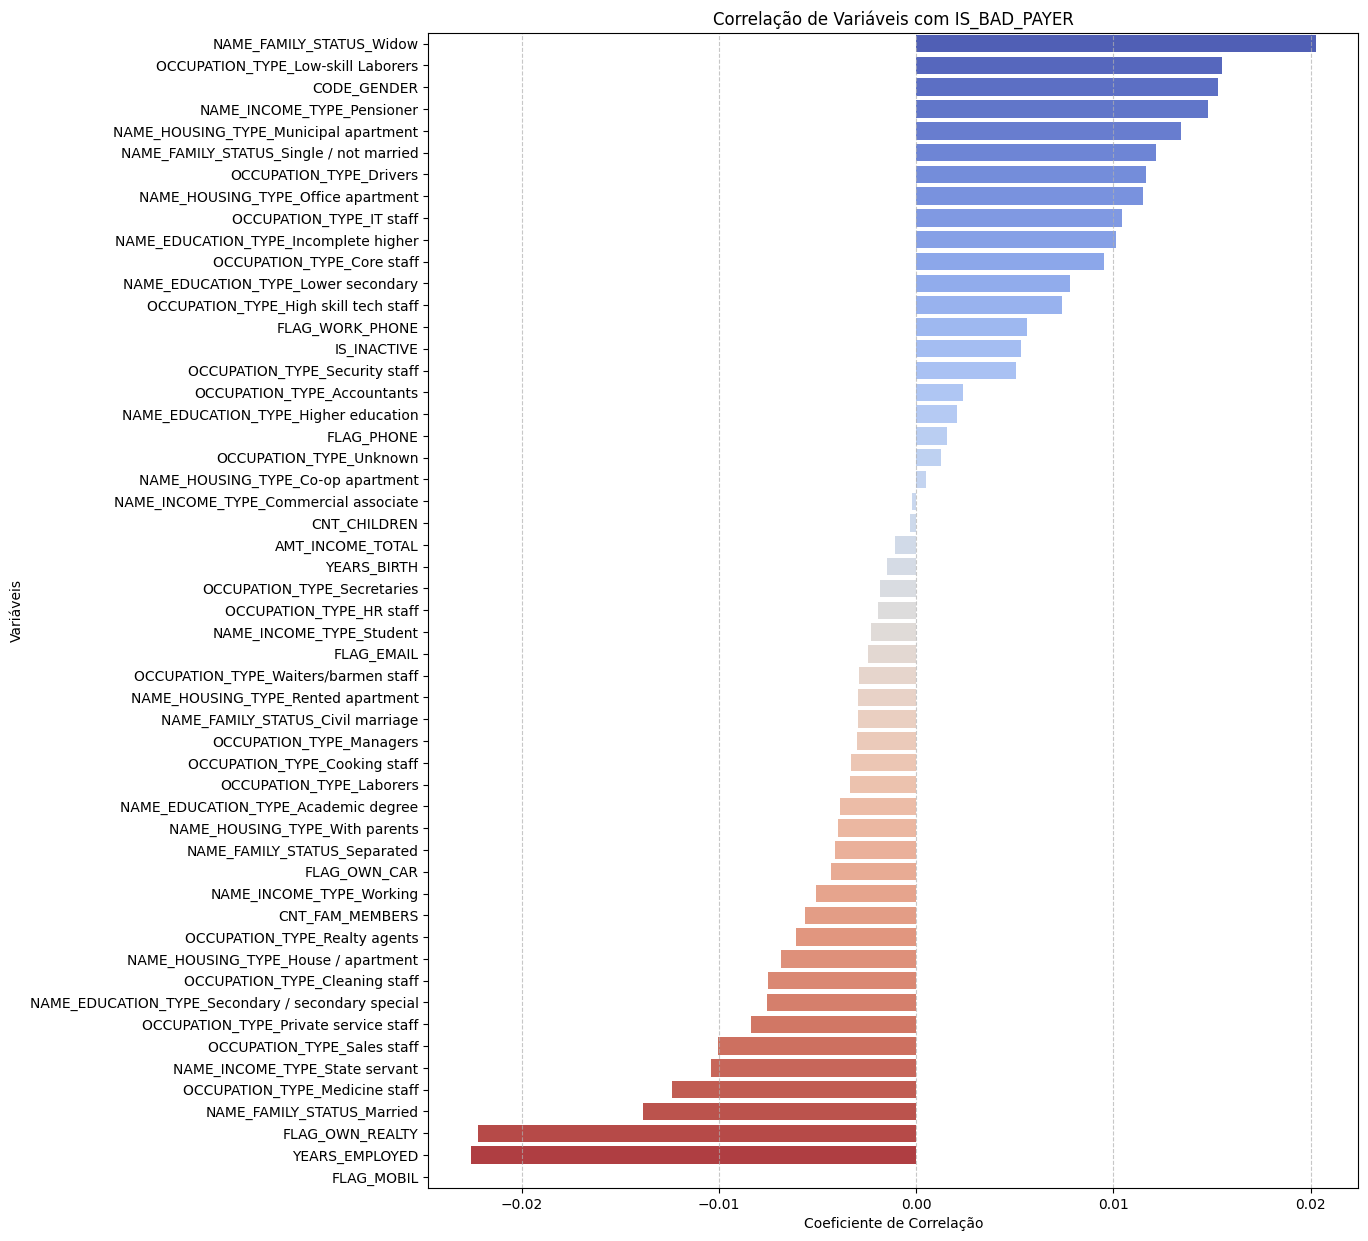

In [52]:
# Calcular a correlação de todas as variáveis com a variável alvo 'IS_BAD_PAYER'
correlations_with_target = df_numerical_corr.corrwith(df_numerical_corr['IS_BAD_PAYER']).sort_values(ascending=False)

# Excluir a correlação da própria variável alvo consigo mesma
correlations_with_target = correlations_with_target.drop('IS_BAD_PAYER')

plt.figure(figsize=(12, 15))
sns.barplot(x=correlations_with_target.values, y=correlations_with_target.index, palette='coolwarm')
plt.title('Correlação de Variáveis com IS_BAD_PAYER')
plt.xlabel('Coeficiente de Correlação')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Análise de Correlação (coeficiente de Pearson) com a Variável Alvo (`IS_BAD_PAYER`)

Ao analisarmos o gráfico de barras que apresenta os coeficientes de correlação linear das variáveis numéricas e codificadas com o indicador de mau pagador (`IS_BAD_PAYER`), podemos destacar os seguintes pontos:

1. **Ausência de Relações Lineares Fortes:** Nenhuma variável isolada possui um coeficiente de correlação linear forte (ex.: acima de 0,5) com a inadimplência.
2. **Baixa Correlação das Variáveis Cadastrais:** Atributos demográficos como OCCUPATION_TYPE, NAME_HOUSE_TYPING_Co Op Apartment, NAME_INCOME_TYPE_Comercial Associate e CNT_CHILDREN apresentam coeficientes extremamente próximos de zero.

Barras para a Direita (Valores Positivos): Indicam uma relação direta: quanto maior o valor dessa variável, maior é a probabilidade de o cliente ser um mau pagador.

Barras para a Esquerda (Valores Negativos): Indicam uma relação inversa: quanto maior o valor dessa variável, menor é a probabilidade de o cliente ser um mau pagador, ou seja, são fatores de proteção/redução de risco. Exemplo: a variável YEARS_EMPLOYED (tempo de emprego) é correlação negativa, indicando que maior estabilidade financeira reduz o risco de inadimplência.

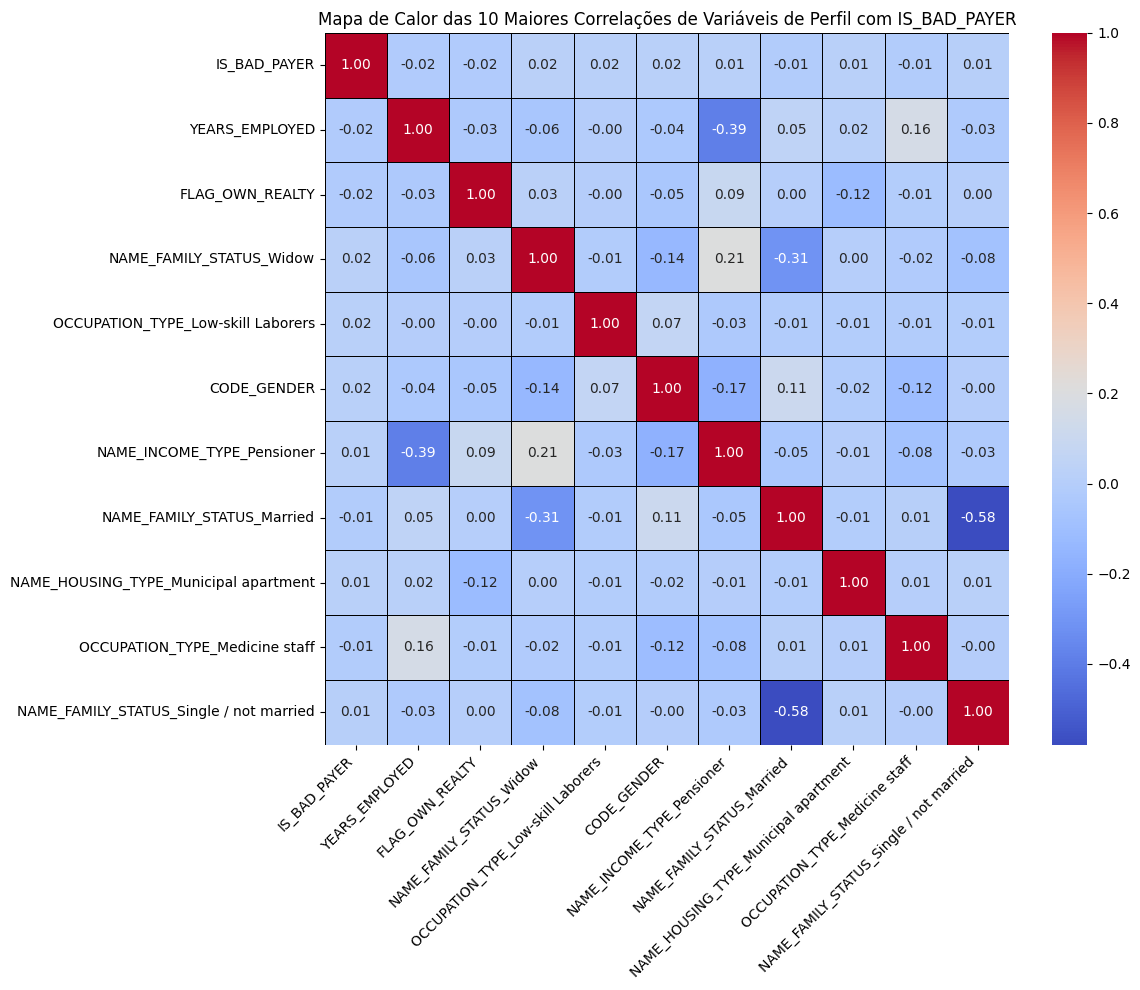

In [53]:
#Análise das variáveis pelo mapa de calor

profile_cols_non_credit = [
    "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY", "CNT_CHILDREN",
    "AMT_INCOME_TOTAL", "YEARS_BIRTH", "YEARS_EMPLOYED", "IS_INACTIVE",
    "CNT_FAM_MEMBERS", "FLAG_WORK_PHONE", "FLAG_PHONE", "FLAG_EMAIL"
] + list(df_encoded_cols.columns)

# Incluir a variável alvo para calcular as correlações
profile_cols_with_target = profile_cols_non_credit + ['IS_BAD_PAYER']

# Filtrar df_numerical_corr para incluir apenas as colunas de perfil selecionadas
df_profile_corr_filtered = df_numerical_corr[profile_cols_with_target]

# Calcular a correlação de todas as variáveis de perfil com a variável alvo 'IS_BAD_PAYER'
# Ordenar pela correlação absoluta e selecionar as top 10 (excluindo a própria IS_BAD_PAYER)
correlations_with_target_profile = df_profile_corr_filtered.corrwith(df_profile_corr_filtered['IS_BAD_PAYER']).abs().sort_values(ascending=False)

top_profile_features_for_heatmap = correlations_with_target_profile.drop('IS_BAD_PAYER').head(10).index.tolist()

# Adicionar IS_BAD_PAYER de volta ao início para visualização no heatmap
top_profile_features_for_heatmap = ['IS_BAD_PAYER'] + top_profile_features_for_heatmap

# Calcular a matriz de correlação para as variáveis de perfil selecionadas
profile_correlation_matrix = df_profile_corr_filtered[top_profile_features_for_heatmap].corr()

# Plotar o mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(profile_correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Mapa de Calor das 10 Maiores Correlações de Variáveis de Perfil com IS_BAD_PAYER')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Com base no mapa de calor das 10 maiores correlações de variáveis de perfil com `IS_BAD_PAYER`, podemos observar os seguintes pontos:

**Correlações com `IS_BAD_PAYER` (Variável Alvo):**

*   **`CODE_GENDER` (0.02):** Apresenta uma correlação positiva muito fraca com `IS_BAD_PAYER`. Isso sugere que o gênero, por si só, tem uma influência mínima (quase insignificante) na probabilidade de ser um mau pagador. (Lembre-se que 'M' foi mapeado para 1 e 'F' para 0).
*   **`OCCUPATION_TYPE_Low-skill Laborers` (0.02):** Similarmente, clientes classificados como 'Low-skill Laborers' mostram uma correlação positiva muito fraca.
*   **`YEARS_EMPLOYED` (-0.02):** Uma correlação negativa muito fraca. Isso indica que, à medida que os anos de emprego aumentam, a probabilidade de ser um mau pagador diminui ligeiramente, o que é um comportamento esperado para maior estabilidade financeira, mas a relação é quase imperceptível.

## 4. Outliers

**Interpretação:** _remover, winsorizar ou manter? Justifique._

In [54]:
# Identificar colunas numéricas para análise de outliers
numerical_cols_for_outlier_check = df_final.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Excluir colunas já tratadas ou que não fazem sentido para detecção de outliers por IQR
# 'ID' é um identificador
# 'DAYS_BIRTH' e 'DAYS_EMPLOYED' foram transformadas em 'YEARS_BIRTH' e 'YEARS_EMPLOYED'
# 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'IS_INACTIVE', 'IS_BAD_PAYER' são binárias ou flags
excluded_cols = [
    'ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE',
    'FLAG_PHONE', 'FLAG_EMAIL', 'IS_INACTIVE', 'IS_BAD_PAYER',
]
numerical_cols_for_outlier_check = [
    col for col in numerical_cols_for_outlier_check if col not in excluded_cols
]

print("Análise de Outliers para as seguintes colunas:", numerical_cols_for_outlier_check)
print("\n" + "-"*50 + "\n")

outlier_summary = {}

for col in numerical_cols_for_outlier_check:
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = df_final[df_final[col] < lower_bound]
    outliers_high = df_final[df_final[col] > upper_bound]

    num_outliers = len(outliers_low) + len(outliers_high)
    total_rows = len(df_final)
    percentage_outliers = (num_outliers / total_rows) * 100

    outlier_summary[col] = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Number of Outliers': num_outliers,
        'Percentage of Outliers': percentage_outliers
    }

    print(f"Variável: {col}")
    print(f"  Q1 (25º percentil): {Q1:.2f}")
    print(f"  Q3 (75º percentil): {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Limite Inferior (lower_bound): {lower_bound:.2f}")
    print(f"  Limite Superior (upper_bound): {upper_bound:.2f}")
    print(f"  Número de outliers: {num_outliers}")
    print(f"  Proporção de outliers: {percentage_outliers:.2f}%")

    if num_outliers > 0:
        print("  **Outliers detectados! Considerar tratamento (e.g., capping/winsorização) se a proporção for significativa.**")
    else:
        print("  Nenhum outlier detectado pela regra do IQR.")
    print("\n" + "-"*50 + "\n")

Análise de Outliers para as seguintes colunas: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'YEARS_BIRTH', 'YEARS_EMPLOYED']

--------------------------------------------------

Variável: CNT_CHILDREN
  Q1 (25º percentil): 0.00
  Q3 (75º percentil): 1.00
  IQR: 1.00
  Limite Inferior (lower_bound): -1.50
  Limite Superior (upper_bound): 2.50
  Número de outliers: 508
  Proporção de outliers: 1.39%
  **Outliers detectados! Considerar tratamento (e.g., capping/winsorização) se a proporção for significativa.**

--------------------------------------------------

Variável: AMT_INCOME_TOTAL
  Q1 (25º percentil): 121500.00
  Q3 (75º percentil): 225000.00
  IQR: 103500.00
  Limite Inferior (lower_bound): -33750.00
  Limite Superior (upper_bound): 380250.00
  Número de outliers: 1529
  Proporção de outliers: 4.19%
  **Outliers detectados! Considerar tratamento (e.g., capping/winsorização) se a proporção for significativa.**

--------------------------------------------------

Variáv

Tratamento de Outliers para CNT_CHILDREN e CNT_FAM_MEMBERS
Conforme a análise de outliers via IQR, as variáveis CNT_CHILDREN e CNT_FAM_MEMBERS possuem uma pequena, mas notável, porcentagem de valores extremos. Para garantir que esses valores não distorçam a modelagem, aplicaremos a técnica de capping. Essa técnica substitui os valores abaixo do limite inferior pelo próprio limite inferior (Q1 - 1.5 * IQR) e os valores acima do limite superior pelo limite superior (Q3 + 1.5 * IQR). Isso restringe os valores dentro de um intervalo mais razoável, preservando a maioria dos dados e reduzindo a influência dos outliers.

Estatísticas descritivas de CNT_CHILDREN após o capping:


count    36457.000000
mean         0.418959
std          0.688709
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          2.500000
Name: CNT_CHILDREN, dtype: float64

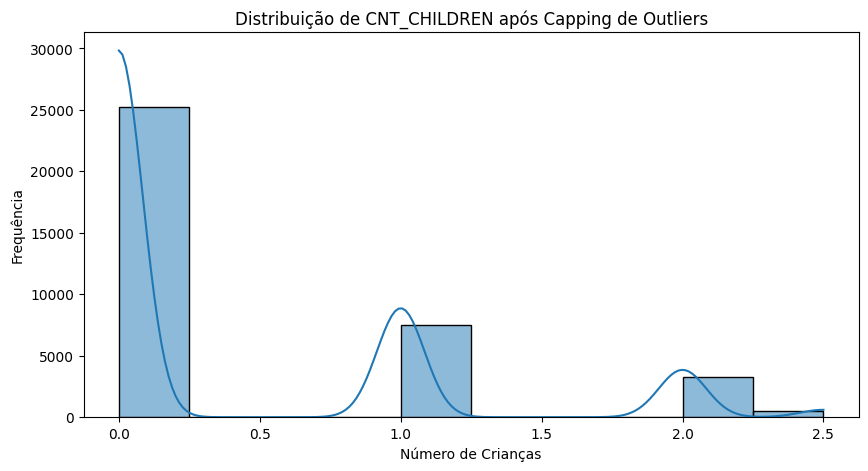

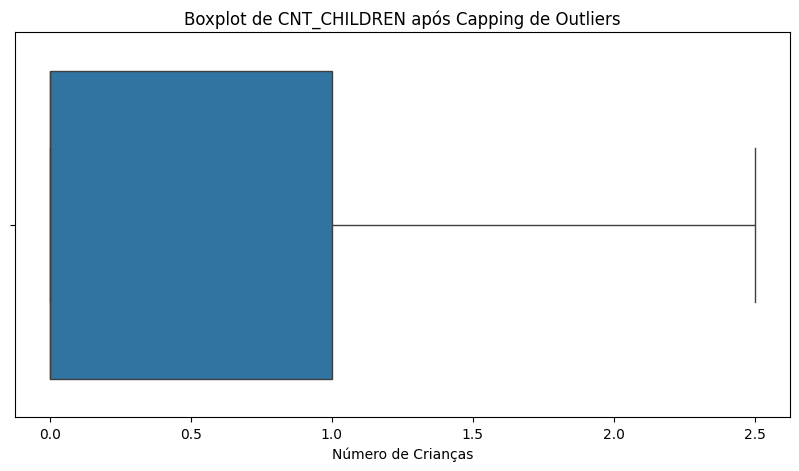

In [55]:
# Aplicar capping para CNT_CHILDREN
lower_bound_children = outlier_summary['CNT_CHILDREN']['Lower Bound']
upper_bound_children = outlier_summary['CNT_CHILDREN']['Upper Bound']

df_final['CNT_CHILDREN'] = np.where(
    df_final['CNT_CHILDREN'] < lower_bound_children, lower_bound_children,
    np.where(df_final['CNT_CHILDREN'] > upper_bound_children, upper_bound_children,
             df_final['CNT_CHILDREN']
    )
)

print("Estatísticas descritivas de CNT_CHILDREN após o capping:")
display(df_final['CNT_CHILDREN'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_CHILDREN'], bins=10, kde=True)
plt.title('Distribuição de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_CHILDREN'])
plt.title('Boxplot de CNT_CHILDREN após Capping de Outliers')
plt.xlabel('Número de Crianças')
plt.show()

Com o capping aplicado, a variável CNT_CHILDREN agora tem seus valores extremos limitados. O histograma e o boxplot mostram uma distribuição mais concentrada, eliminando os outliers que estavam muito além dos limites do IQR. Isso torna a variável mais robusta para análises e modelagens subsequentes.


Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:


count    36457.000000
mean         2.187783
std          0.869257
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max          4.500000
Name: CNT_FAM_MEMBERS, dtype: float64

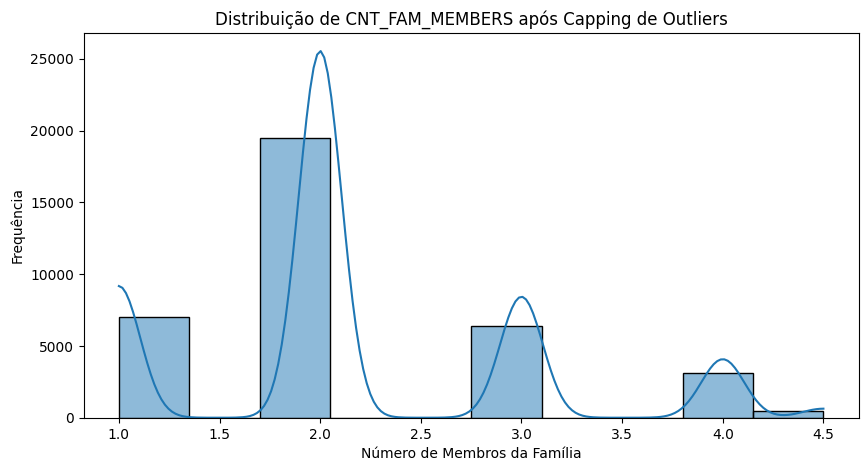

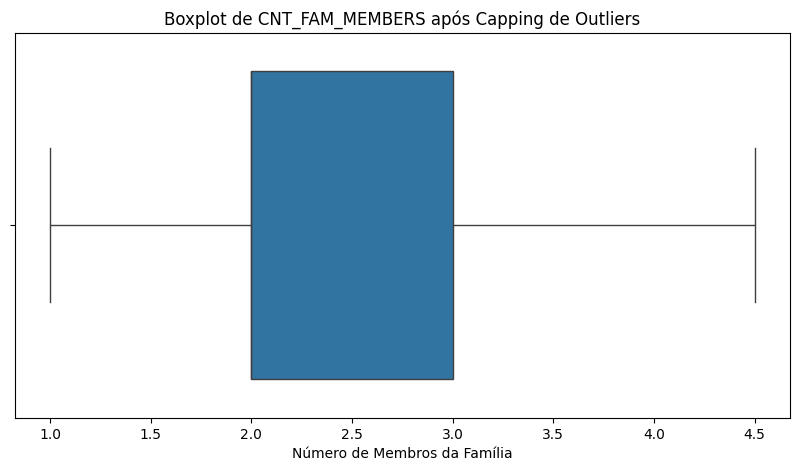

In [56]:
# Aplicar capping para CNT_FAM_MEMBERS
lower_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Lower Bound']
upper_bound_fam = outlier_summary['CNT_FAM_MEMBERS']['Upper Bound']

df_final['CNT_FAM_MEMBERS'] = np.where(
    df_final['CNT_FAM_MEMBERS'] < lower_bound_fam, lower_bound_fam,
    np.where(df_final['CNT_FAM_MEMBERS'] > upper_bound_fam, upper_bound_fam,
             df_final['CNT_FAM_MEMBERS']
    )
)

print("Estatísticas descritivas de CNT_FAM_MEMBERS após o capping:")
display(df_final['CNT_FAM_MEMBERS'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['CNT_FAM_MEMBERS'], bins=10, kde=True)
plt.title('Distribuição de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['CNT_FAM_MEMBERS'])
plt.title('Boxplot de CNT_FAM_MEMBERS após Capping de Outliers')
plt.xlabel('Número de Membros da Família')
plt.show()

Os outliers da variável CNT_FAM_MEMBERS foram tratados. As visualizações confirmam que os valores agora se encontram dentro dos limites definidos pelo IQR, o que contribui para uma melhor representação da população e um desempenho mais estável em modelos de Machine Learning. Ambas as variáveis estão agora mais limpas e preparadas para as próximas etapas.

Tratamento de AMT_INCOME_TOTAL com Transformação Logarítmica.
A variável AMT_INCOME_TOTAL possui uma distribuição assimétrica à direita (cauda longa à direita), com a presença de outliers de alta renda. Para tornar essa distribuição mais próxima de uma normal e reduzir a influência desses valores extremos em modelos de Machine Learning, aplicaremos uma transformação logarítmica (np.log1p). Esta transformação é especialmente útil para dados que são estritamente positivos e que exibem uma grande variação, comprimindo os valores maiores e expandindo os menores.

Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:


count    36457.000000
mean        12.018808
std          0.480501
min         10.203629
25%         11.707678
50%         11.967187
75%         12.323860
max         14.269766
Name: AMT_INCOME_TOTAL_LOG, dtype: float64

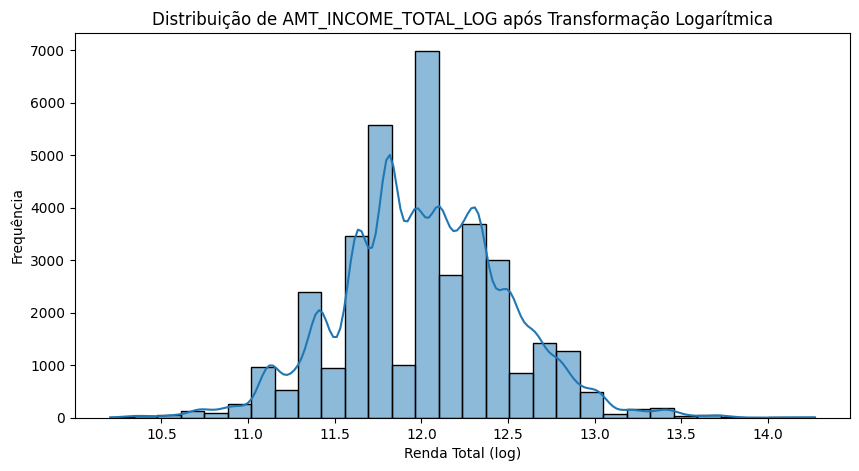

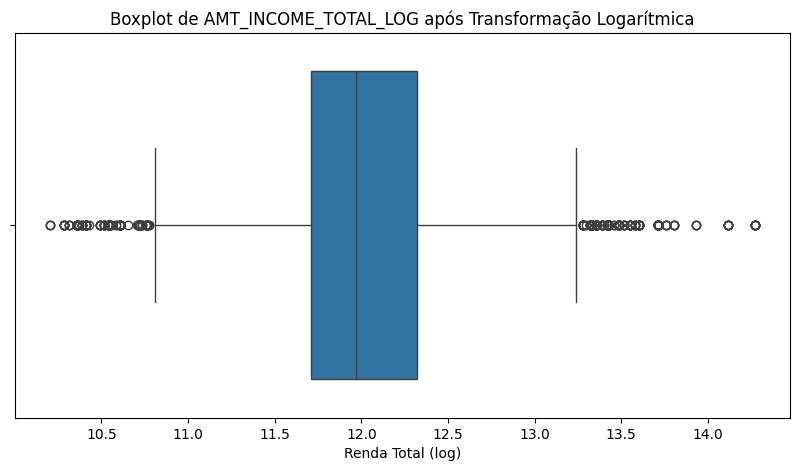

In [57]:
# Aplicar transformação logarítmica (log1p para lidar com valores zero, se existirem)
df_final['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_final['AMT_INCOME_TOTAL'])

print("Estatísticas descritivas de AMT_INCOME_TOTAL_LOG após transformação logarítmica:")
display(df_final['AMT_INCOME_TOTAL_LOG'].describe())

# Visualizar a distribuição após o tratamento
plt.figure(figsize=(10, 5))
sns.histplot(df_final['AMT_INCOME_TOTAL_LOG'], bins=30, kde=True)
plt.title('Distribuição de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.ylabel('Frequência')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x=df_final['AMT_INCOME_TOTAL_LOG'])
plt.title('Boxplot de AMT_INCOME_TOTAL_LOG após Transformação Logarítmica')
plt.xlabel('Renda Total (log)')
plt.show()

Após a aplicação da transformação logarítmica (np.log1p), a distribuição de AMT_INCOME_TOTAL (agora AMT_INCOME_TOTAL_LOG) tornou-se visivelmente mais simétrica e próxima de uma distribuição normal. O histograma mostra uma forma mais equilibrada, e o boxplot indica uma redução significativa na dispersão dos outliers, que foram trazidos para mais perto do corpo principal da distribuição. Essa transformação é fundamental para garantir que a variável contribua de forma mais eficaz e menos enviesada nos modelos preditivos.

## 5. Balanceamento de classes

**Interpretação:** _qual a proporção entre as classes e o que isso implica na escolha das métricas?_

Com a criação da variável IS_BAD_PAYER e a consolidação do cadastro com o histórico de crédito (`df_final`), observou-se um forte desbalanceamento entre as classes, com aproximadamente **98,31% de bons pagadores (0)** e **1,69% de maus pagadores (1)**.

Apesar do desequilíbrio, a proporção encontrada é compatível com o cenário real de concessão de crédito, onde a inadimplência severa (atrasos superiores a 60 dias) representa a minoria dos casos. Dessa forma, optou-se por manter a definição da variável alvo e tratar o desbalanceamento posteriormente por meio de técnicas específicas de modelagem.

### Implicações para a escolha das métricas:

Em um cenário de classes altamente desbalanceadas, métricas como a **Acurácia (Accuracy)** podem ser enganosas, pois um modelo simplista que classifique todos os clientes como "bons pagadores" atingiria 98,31% de acurácia, falhando completamente em seu objetivo de negócio (detectar o risco).

Para avaliar o desempenho do modelo de forma realista, utilizaremos métricas robustas ao desbalanceamento:

*   **Precisão (Precision):** A proporção de identificações positivas corretas (dos que o modelo classificou como mau pagador, quantos realmente eram).
*   **Recall (Sensibilidade):** A proporção de positivos reais que foram identificados corretamente (dos que são realmente maus pagadores, quantos o modelo conseguiu detectar).
*   **F1-Score:** A média harmônica entre precisão e recall, ideal para cenários com forte desbalanceamento quando buscamos equilíbrio entre as duas métricas.
*   **AUC-ROC:** Avalia a capacidade do modelo de distinguir entre as classes sob diferentes limiares de classificação.
*   **Matriz de Confusão:** Para monitorar diretamente os Erros do Tipo I (Falsos Positivos) e Tipo II (Falsos Negativos).

*(Nota: A aplicação prática de técnicas de balanceamento, como oversampling/SMOTE ou undersampling, será realizada no **Notebook 03** utilizando `Pipeline`. Isso evitará o vazamento de dados (data leakage) entre os conjuntos de treino e teste, garantindo uma validação fidedigna do modelo.)*

## 6. Síntese da EDA

_Amarre os achados em uma narrativa única — é ela que vira o storytelling da apresentação._

**Análise Exploratória de Dados: Entendendo o Risco de Crédito**

Nosso objetivo fundamental neste projeto é construir um modelo robusto para prever o risco de crédito, classificando os solicitantes entre "bons pagadores" e "maus pagadores". Para isso, realizamos a Análise Exploratória de Dados (EDA), trabalhando com duas bases de dados: `df_application`, contendo informações demográficas e de emprego dos solicitantes, e `df_credit`, que detalha o histórico de pagamentos.

#### **1. Consolidação e Preparação dos Dados**

Iniciamos com o `df_application`, um vasto registro de 438.557 linhas e 18 variáveis. Um dos primeiros desafios foi o tratamento da variável `OCCUPATION_TYPE`, que apresentava um grande número de valores ausentes, preenchidos de forma estratégica com 'Unknown' para preservar a informação. Identificamos também um pequeno número de IDs duplicados com informações conflitantes, e um volume considerável de linhas totalmente idênticas (exceto pelo ID), que foram mantidos para análise contextual posterior.

Paralelamente, o `df_credit`, com mais de 1 milhão de registros, foi a base para definir a variável alvo: `IS_BAD_PAYER`. A fusão desses dois conjuntos de dados nos proporcionou uma visão completa de cada solicitante.

#### **2. A Variável Alvo e o Desafio do Desbalanceamento**

Classificamos como 'mau pagador' (1) clientes que apresentaram um atraso de **60 dias ou mais** (ou seja, `STATUS` igual ou superior a 2) em seu histórico de crédito; os demais foram categorizados como 'bom pagador' (0).

Esta etapa revelou um achado crítico: um **desbalanceamento severo** na distribuição das classes. Observamos que aproximadamente **98,31%** dos clientes são 'bons pagadores', enquanto apenas **1,69%** são 'maus pagadores'. Este cenário, comum em problemas de risco de crédito, exige uma abordagem cuidadosa na modelagem. Métricas de avaliação tradicionais como a acurácia podem ser enganosas, pois um modelo poderia atingir alta acurácia simplesmente prevendo a classe majoritária.

Para contornar isso, enfatizamos que nosso modelo será avaliado por métricas mais robustas, como **Precisão**, **Recall**, **F1-Score**, **AUC-ROC** e a **Matriz de Confusão**, que nos darão uma visão mais fiel da capacidade do modelo em identificar os 'maus pagadores'. Além disso, destacamos a necessidade de balanceamento de classes para garantir que o modelo não seja viesado.

#### **3. Tratamento de Outliers e Transformações de Variáveis Chave**

A qualidade dos dados é fundamental. Em `YEARS_EMPLOYED`, identificamos valores de `-1000`, que representavam clientes inativos ou pensionistas. Corrigimos isso substituindo por `0` e criamos a variável `IS_INACTIVE` para capturar essa condição de forma explícita. Outliers em `CNT_CHILDREN` e `CNT_FAM_MEMBERS` também foram tratados através da técnica de "capping" baseada no Intervalo Interquartil (IQR), minimizando seu impacto sem distorcer a distribuição principal.

Uma transformação foi aplicada à `AMT_INCOME_TOTAL`. Dada a sua distribuição altamente assimétrica e a presença de outliers de alta renda, aplicamos uma **transformação logarítmica (`np.log1p`)**. O resultado foi uma distribuição visivelmente mais simétrica e menos suscetível à influência de valores extremos, tornando-a muito mais adequada para o aprendizado de máquina.

#### **4. Análise de Correlação e Principais Insights das Variáveis**

Nossa EDA também nos forneceu insights valiosos sobre o perfil dos solicitantes e a relação entre as variáveis:

*   **Relação com IS_BAD_PAYER:** A análise de correlação destacou que variáveis de perfil como gênero, tipo de ocupação e tipo de renda mostraram correlações muito fracas com a variável alvo, indicando que, isoladamente, têm pouca capacidade preditiva para "mau pagador".
*   **Multicolinearidade:** Observamos alta multicolinearidade entre variáveis  entre `NAME_FAMILY_STATUS_Single / not married` e `NAME_FAMILY_STATUS_Married` (-0.58), e `NAME_INCOME_TYPE_Pensioner` e `YEARS_EMPLOYED` (-0.39). O tratamento dessas multicolinearidades, através de possível remoção de variáveis redundantes, será tratada posteriormente.
*   **Distribuições:**
    *   **Renda (`AMT_INCOME_TOTAL_LOG`)**: A maioria concentra-se em faixas de renda média a baixa, com a transformação logarítmica aprimorando a distribuição.
    *   **Idade (`YEARS_BIRTH`)**: A base de clientes é predominantemente jovem a adulta, com a maioria entre 30 e 40 anos.
    *   **Emprego (`YEARS_EMPLOYED`)**: Há um pico significativo de clientes com 0 anos de emprego (inativos), decrescendo com o aumento dos anos de serviço.
    *   **Gênero (`CODE_GENDER`)**: Uma predominância feminina na base de dados.
    *   **Ocupação (`OCCUPATION_TYPE`)**: 'Unknown', 'Laborers' e 'Core staff' são as categorias mais comuns.
    *   **Posse de Bens**: A maioria dos clientes não possui carro, mas uma parcela significativa possui imóvel.
    *   **Educação (`NAME_EDUCATION_TYPE`)**: 'Secondary / secondary special' e 'Higher education' são os níveis educacionais mais frequentes.

#### **Conclusão: Dados Prontos para a Modelagem**

Após a limpeza e transformação, nossos dados estão em um estado compreensível e mais robusto. Os desafios de outliers e algumas multicolinearidades foram identificados e tratados, já o desbalanceamento de classes foi identificado e será tratado no notebook 03, dentro de um Pipeline, para que não haja vazamento de dados. Embora tenhamos realizado análises e tratamentos preliminares de outliers nesta fase de exploração, as etapas de pré-processamento definitivas serão consolidadas em um Pipeline no Notebook 02, garantindo integridade metodológica total.

Agora, focaremos na construção de modelos de Machine Learning eficazes e justos, capazes de prever o risco de crédito com precisão, contribuindo significativamente para a tomada de decisões estratégicas.